# Url classification using standard features

In [1]:
import sys
from pathlib import Path

# Allow imports from ../src when running from notebooks/
sys.path.append(str(Path('..').resolve() / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

from hf_phishing_url.constants import DATASET_ID, LABEL_COL
from hf_phishing_url.data import map_labels
from hf_phishing_url.experiment import load_default_splits
from hf_phishing_url.feature_extraction import UrlFeatureExtractor, UrlTokenizer

RANDOM_STATE = 42
VAL_SIZE = 0.2

pd.set_option('display.max_columns', 200)

## Reading data

In [2]:
splits = load_default_splits(dataset_id=DATASET_ID)
train_raw = splits.train.copy()
print('Dataset:', DATASET_ID)
print('Raw training data shape:', train_raw.shape)
display(train_raw.head(3))

/home/tkl/files/projects/ai_ml/ml-2-url-img-classifier/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset: pirocheto/phishing-url
Raw training data shape: (7658, 89)


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,nb_underscore,nb_tilde,nb_percent,nb_slash,nb_star,nb_colon,nb_comma,nb_semicolumn,nb_dollar,nb_space,nb_www,nb_com,nb_dslash,http_in_path,https_token,ratio_digits_url,ratio_digits_host,punycode,port,tld_in_path,tld_in_subdomain,abnormal_subdomain,nb_subdomains,prefix_suffix,random_domain,shortening_service,path_extension,nb_redirection,nb_external_redirection,length_words_raw,char_repeat,shortest_words_raw,shortest_word_host,shortest_word_path,longest_words_raw,longest_word_host,longest_word_path,avg_words_raw,avg_word_host,avg_word_path,phish_hints,domain_in_brand,brand_in_subdomain,brand_in_path,suspecious_tld,statistical_report,nb_hyperlinks,ratio_intHyperlinks,ratio_extHyperlinks,ratio_nullHyperlinks,nb_extCSS,ratio_intRedirection,ratio_extRedirection,ratio_intErrors,ratio_extErrors,login_form,external_favicon,links_in_tags,submit_email,ratio_intMedia,ratio_extMedia,sfh,iframe,popup_window,safe_anchor,onmouseover,right_clic,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,https://www.todayshomeowner.com/how-to-make-ho...,82,23,0,2,7,0,0,0,0,0,0,0,0,4,0,1,0,0,0,0,1,0,0,0,0,0.000000,0.0,0,0,0,0,0,2,0,0,0,0,1,0,10,3,2,3,2,15,15,12,6.000000,9.0,5.2500,0,0,0,0,0,0,502,0.918327,0.081673,0,2,0,0.146341,0,0.097561,0,1,28.571429,0,99.170124,0.829876,0,0,0,89.539749,0,0,0,1,1,0,240,8892,67860,0,1,4,legitimate
1,http://thapthan.ac.th/information/confirmation...,93,14,1,2,0,0,0,0,0,0,0,0,0,7,0,1,0,0,0,0,0,0,0,0,1,0.258065,0.0,0,0,0,0,0,2,0,0,0,0,1,0,6,3,4,8,4,32,8,32,12.500000,8.0,13.4000,0,0,0,0,0,0,12,0.916667,0.083333,0,0,0,0.000000,0,0.000000,0,0,83.333333,0,100.000000,0.000000,0,0,0,0.000000,0,0,0,1,0,1,0,2996,4189860,0,1,2,phishing
2,http://app.dialoginsight.com/T/OFC4/L2S/3888/B...,121,21,1,3,0,0,0,0,0,0,0,0,0,17,0,1,0,0,0,0,0,0,0,0,1,0.371901,0.0,0,0,0,0,0,3,0,0,1,0,3,0,18,5,1,3,1,13,13,8,5.166667,8.0,4.8125,1,0,0,0,0,0,83,0.614458,0.385542,0,1,0,0.187500,0,0.000000,0,1,92.307692,0,100.000000,0.000000,0,0,0,9.375000,0,0,0,1,1,0,30,2527,346022,0,1,3,phishing


In [3]:
nulls = train_raw.isna().sum().sort_values(ascending=False)
nulls = nulls[nulls > 0]
print(f'Columns with nulls: {len(nulls)}')
# display(nulls.head(30))

Columns with nulls: 0


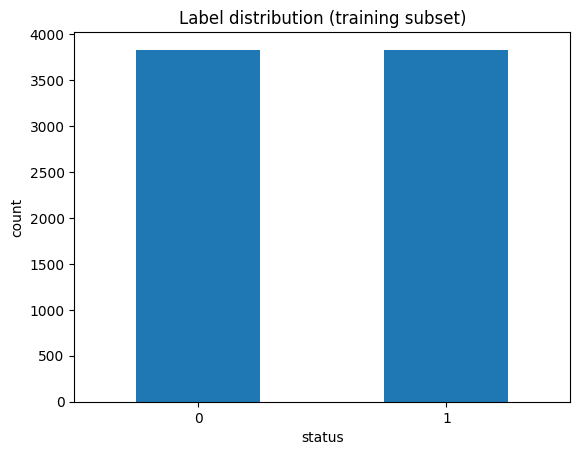

In [4]:
train_mapped = map_labels(train_raw)
counts = train_mapped[LABEL_COL].value_counts().sort_index()

ax = counts.plot(kind='bar', title='Label distribution (training subset)', rot=0)
ax.set_label('status (1 = phishing, 0 = legitimate)')
ax.set_ylabel('count')
plt.show()

## Preprocessing

In [5]:
train_base = train_mapped[['url', LABEL_COL]].copy()
display(train_base.head(3))

,url,status
0,https://www.todayshomeowner.com/how-to-make-ho...,0
1,http://thapthan.ac.th/information/confirmation...,1
2,http://app.dialoginsight.com/T/OFC4/L2S/3888/B...,1


In [6]:
tokenizer = UrlTokenizer()

single_url = train_base.iloc[0]['url']
toks = tokenizer.tokenize(single_url)

display(toks)

{'normalized': 'https://www.todayshomeowner.com/how-to-make-homemade-insecticidal-soap-for-plants/',
 'hostname': 'www.todayshomeowner.com',
 'raw_lower': 'https://www.todayshomeowner.com/how-to-make-homemade-insecticidal-soap-for-plants/',
 'host_lower': 'www.todayshomeowner.com',
 'path_lower': '/how-to-make-homemade-insecticidal-soap-for-plants/',
 'raw_tokens': ['https',
  'www',
  'todayshomeowner',
  'com',
  'how',
  'to',
  'make',
  'homemade',
  'insecticidal',
  'soap',
  'for',
  'plants'],
 'host_tokens': ['www', 'todayshomeowner', 'com'],
 'path_tokens': ['how',
  'to',
  'make',
  'homemade',
  'insecticidal',
  'soap',
  'for',
  'plants'],
 'subdomain_tokens': ['www'],
 'tld': 'com'}

In [7]:
extractor = UrlFeatureExtractor()

single_url = train_base.iloc[0]['url']
features = extractor.extract_one(single_url)

display(features)

{'url': 'https://www.todayshomeowner.com/how-to-make-homemade-insecticidal-soap-for-plants/',
 'length_url': 82,
 'length_hostname': 23,
 'ip': 0,
 'nb_dots': 2,
 'nb_hyphens': 7,
 'nb_at': 0,
 'nb_qm': 0,
 'nb_and': 0,
 'nb_or': 0,
 'nb_eq': 0,
 'nb_underscore': 0,
 'nb_tilde': 0,
 'nb_percent': 0,
 'nb_slash': 4,
 'nb_star': 0,
 'nb_colon': 1,
 'nb_comma': 0,
 'nb_semicolumn': 0,
 'nb_dollar': 0,
 'nb_space': 0,
 'nb_www': 1,
 'nb_com': 1,
 'nb_dslash': 1,
 'nb_subdomains': 1,
 'ratio_digits_url': 0.0,
 'ratio_digits_host': 0.0,
 'http_in_path': 0,
 'tld_in_path': 0,
 'tld_in_subdomain': 0,
 'prefix_suffix': 0,
 'path_extension': 0,
 'shortest_words_raw': 2,
 'shortest_word_host': 3,
 'shortest_word_path': 2,
 'longest_words_raw': 15,
 'longest_word_host': 15,
 'longest_word_path': 12,
 'brand_in_subdomain': 0,
 'brand_in_path': 0}

## Training Model

### Define Model Pipeline

In [8]:
# Train/val split + ROC/AUC visualization (URL-only features)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.compose import ColumnTransformer

from hf_phishing_url.feature_extraction import UrlFeatureExtractor, URLFeatures
from hf_phishing_url.word2vec_embedding import UrlWord2VecVectorizer

standard_features = [
    k for k, _ in URLFeatures.__annotations__.items()
    if k != 'url'
]

'''
Requires columns: 
- url
- ...standard features
'''
candidate_models = [
    (
        'hgb',
        Pipeline([
            # (
            #     'features',
            #     ColumnTransformer([
            #         ('embed', UrlWord2VecVectorizer(), 'url'),
            #         ('num', 'passthrough', standard_features),
            #     ]),
            # ),
            (
                'clf', 
                HistGradientBoostingClassifier(
                    random_state=RANDOM_STATE,
                    max_depth=None,
                    learning_rate=0.1,
                )
            ),
        ]),
    ),
]

print(standard_features)
print(len(standard_features))

['length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens', 'nb_at', 'nb_qm', 'nb_and', 'nb_or', 'nb_eq', 'nb_underscore', 'nb_tilde', 'nb_percent', 'nb_slash', 'nb_star', 'nb_colon', 'nb_comma', 'nb_semicolumn', 'nb_dollar', 'nb_space', 'nb_www', 'nb_com', 'nb_dslash', 'nb_subdomains', 'ratio_digits_url', 'ratio_digits_host', 'http_in_path', 'tld_in_path', 'tld_in_subdomain', 'prefix_suffix', 'path_extension', 'shortest_words_raw', 'shortest_word_host', 'shortest_word_path', 'longest_words_raw', 'longest_word_host', 'longest_word_path', 'brand_in_subdomain', 'brand_in_path']
39


### Prepare the data

In [16]:
from hf_phishing_url.feature_extraction import UrlFeatureExtractor

extractor = UrlFeatureExtractor()

feature_rows = extractor.extract_many(train_base['url'].astype(str).tolist())

y = train_base[LABEL_COL]
X = feature_rows[feature_rows.columns.drop('url')]

X_tr, X_val, y_tr, y_val = train_test_split(
    X,
    y,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print('X_train shape: ', X_tr.shape)
print('y_train shape: ', y_tr.shape)
print('X_val shape: ', X_val.shape)
print('y_val shape: ', y_val.shape)
print('Columns', X_tr.columns)


X_train shape:  (6126, 39)
y_train shape:  (6126,)
X_val shape:  (1532, 39)
y_val shape:  (1532,)
Columns Index(['length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens', 'nb_at',
       'nb_qm', 'nb_and', 'nb_or', 'nb_eq', 'nb_underscore', 'nb_tilde',
       'nb_percent', 'nb_slash', 'nb_star', 'nb_colon', 'nb_comma',
       'nb_semicolumn', 'nb_dollar', 'nb_space', 'nb_www', 'nb_com',
       'nb_dslash', 'nb_subdomains', 'ratio_digits_url', 'ratio_digits_host',
       'http_in_path', 'tld_in_path', 'tld_in_subdomain', 'prefix_suffix',
       'path_extension', 'shortest_words_raw', 'shortest_word_host',
       'shortest_word_path', 'longest_words_raw', 'longest_word_host',
       'longest_word_path', 'brand_in_subdomain', 'brand_in_path'],
      dtype='str')


### Model training

In [17]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

def evaluate_model(model, X_val, y_val) -> tuple[dict, list, list] :
    '''
    Returns:
    - metrics: dictionary containing metrics.
    - y_pred: final predicted class label for each sample.
    - y_score: continuous confidence score that sample belongs to positive class.
    '''
    y_pred = model.predict(X_val)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_val)[:, 1]
    else:
        scores = model.decision_function(X_val)
        y_score = 1 / (1 + np.exp(-scores))

    metrics = {
        "roc_auc": roc_auc_score(y_val, y_score),
        "accuracy": accuracy_score(y_val, y_pred),
        "f1": f1_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred),
        "recall": recall_score(y_val, y_pred),
    }

    return metrics, y_pred, y_score

# Training a single model
name, model = candidate_models[0]

model.fit(X_tr, y_tr)

metrics, y_pred, y_score = evaluate_model(model, X_val, y_val)

results = []
results.append({
    "model": name,
    **metrics
})

### Performance visualization

(7658,) [0.95368918 0.99874742 0.98339195 ... 0.99841234 0.99871934 0.05548235]


<Figure size 700x600 with 0 Axes>

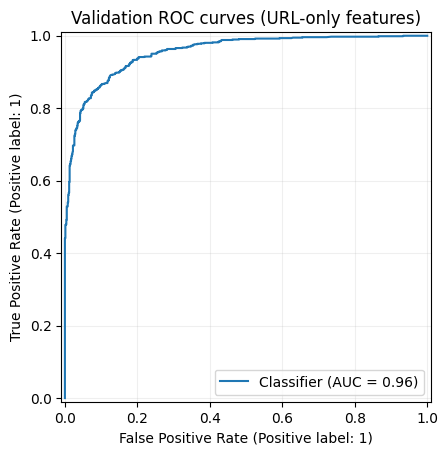

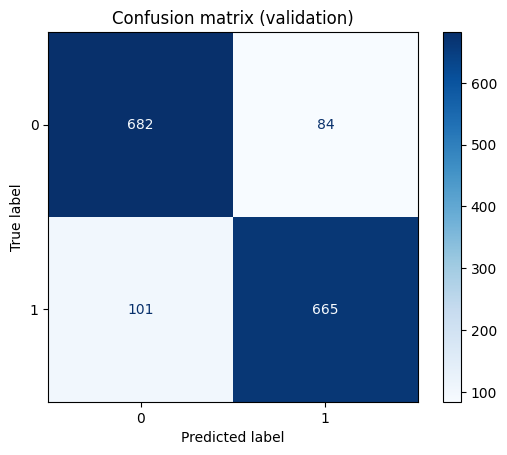

,model,roc_auc,accuracy,f1,precision,recall
0,hgb,0.955034,0.879243,0.877888,0.88785,0.868146


In [18]:
from sklearn.metrics import (
    RocCurveDisplay, ConfusionMatrixDisplay
)

plt.figure(figsize=(7, 6))

print(y.shape, y_score)

RocCurveDisplay.from_predictions(y_val, y_score)

plt.title('Validation ROC curves (URL-only features)')
plt.grid(True, alpha=0.2)
plt.show()

ConfusionMatrixDisplay.from_predictions(y_val, y_pred, cmap='Blues')

plt.title('Confusion matrix (validation)')
plt.grid(False)
plt.show()

display(pd.DataFrame.from_records(results))